**Hypotesis: Does the model rely on temporal and traffic-source shortcut features
(Month, TrafficType) instead of genuine behavioral signals,
causing performance collapse under distribution shift?**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

RANDOM_STATE = 42

loading dataset and removing PageValue feature

In [2]:
DATA_PATH = "../data/online_shoppers_intention.csv"

df = pd.read_csv(DATA_PATH)

df = df.drop(columns=['PageValues'])

separating features and target

In [3]:
X = df.drop(columns=['Revenue'])
y = df['Revenue']

Feature Types

In [5]:
categorical_features = X.select_dtypes(
    include=['object', 'bool']
).columns.tolist()

numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: ['Month', 'VisitorType', 'Weekend']
Numerical: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']


Preprocessing

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

Train/Test Split (random)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

Model Pipeline

In [8]:
model = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric='logloss'
    ))
])

training model

In [9]:
model.fit(X_train, y_train)

c:\Users\Z_ZENBOOK\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Month', 'VisitorType',
                                                   'Weekend'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

Predictions

In [10]:
y_pred = model.predict(X_test)

y_proba = model.predict_proba(X_test)[:, 1]

Evaluating Model

In [11]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_proba))

Accuracy : 0.8471208434712084
Precision: 0.5268817204301075
Recall   : 0.12827225130890052
F1 Score : 0.2063157894736842
ROC AUC  : 0.7618278381284482


Classification Report

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.86      0.98      0.92      2084
        True       0.53      0.13      0.21       382

    accuracy                           0.85      2466
   macro avg       0.69      0.55      0.56      2466
weighted avg       0.81      0.85      0.81      2466



Confusion Matrix

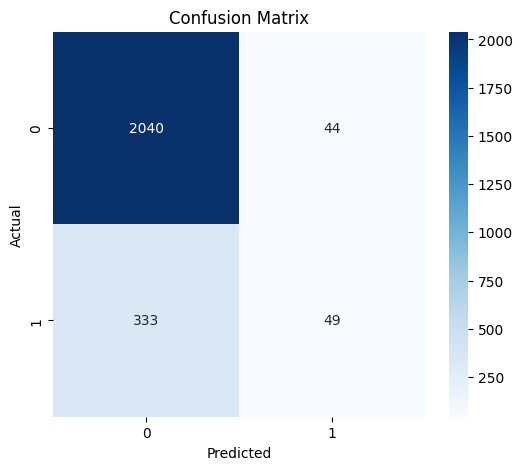

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

_model predicts:
-non-purchase extremely well
-purchase very poorly_

Feature Importance

In [14]:
ohe = model.named_steps['preprocessing'].named_transformers_['cat']

encoded_cat_features = ohe.get_feature_names_out(categorical_features)

all_features = np.concatenate([
    encoded_cat_features,
    numerical_features
])

In [15]:
importances = model.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
7,Month_Nov,0.078449
22,ExitRates,0.075299
12,VisitorType_Returning_Visitor,0.074813
5,Month_Mar,0.043222
20,ProductRelated_Duration,0.040915
9,Month_Sep,0.039876
23,SpecialDay,0.036948
21,BounceRates,0.036121
6,Month_May,0.035375
8,Month_Oct,0.034812


multiple Month indicators dominate the model in addition to VisitorType but TrafficType is not a major predictive signal cotrary to what we suspected after EDA

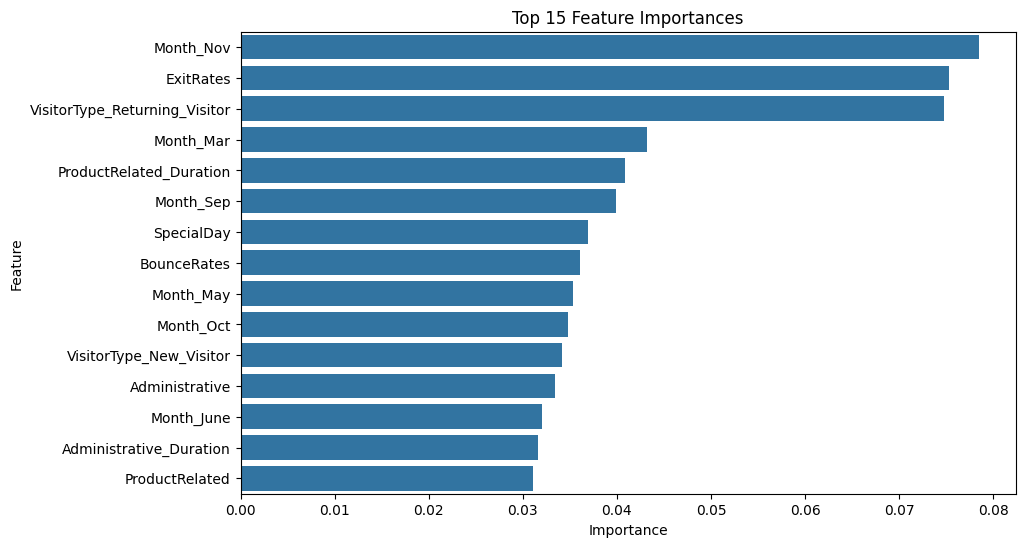

In [16]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Feature Importances")

plt.show()

**we won't confirm the hypothesis but this indicates that the model relies excessively on temporal features (Month) that correlate with purchase probability in the training distribution. This dependence may reduce robustness under temporal distribution shift. Thus in the next notebook we will force the model to fail by training it on the first months of the year and testing on the later ones.**
